Chegou a hora de você testar os conhecimentos desenvolvidos durante a aula. Para isso, vamos utilizar outro dataset em um desafio que será desenvolvido no decorrer do curso. Esse dataset é uma versão modificada do arquivo Oranges vs. Grapefruit presente no site do Kaggle. Portanto, utilizaremos o arquivo raw disponível no GitHub.

Nessa etapa, você deve efetuar a leitura dos dados. Para isso, importe a NumPy e use a função loadtxt. Use o link da url e o parâmetro usecols para pular a primeira coluna. É possível usar np.arange para criar a sequência de números que representam as colunas. Por fim, também é necessário incluir o parâmetro skiprows=1 para que a primeira linha de texto seja desconsiderada na leitura do arquivo.

In [22]:
import numpy as np
url = 'https://raw.githubusercontent.com/allanspadini/numpy/dados/citrus.csv'

dados = np.loadtxt(url, delimiter=',', usecols= np.arange(1, 6, 1) ,skiprows=1)
dados

array([[  2.96,  86.76, 172.  ,  85.  ,   2.  ],
       [  3.91,  88.05, 166.  ,  78.  ,   3.  ],
       [  4.42,  95.17, 156.  ,  81.  ,   2.  ],
       ...,
       [ 15.59, 256.5 , 168.  ,  82.  ,  20.  ],
       [ 15.92, 260.14, 142.  ,  72.  ,  11.  ],
       [ 16.45, 261.51, 152.  ,  74.  ,   2.  ]])

#### Para visualizar melhor com o que estou trabalhando usarei a biblioteca pandas

In [23]:
import pandas as pd

df = pd.read_csv(url)
df

,nome,diametro,peso,vermelho,verde,azul
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
...,...,...,...,...,...,...
9995,grapefruit,15.35,253.89,149,77,20
9996,grapefruit,15.41,254.67,148,68,7
9997,grapefruit,15.59,256.50,168,82,20
9998,grapefruit,15.92,260.14,142,72,11


In [24]:
#Quais frutas eu tenho
print(set(df['nome']))
df.sort_values(by='nome', ascending=False)

df['nome'].value_counts()

{'orange', 'grapefruit'}


nome
orange        5000
grapefruit    5000
Name: count, dtype: int64

In [25]:
laranja_pd = df.query("nome == 'orange'").drop('nome', axis=1)
toranja_pv = df.query("nome == 'grapefruit'").drop('nome', axis=1)
laranja_pd

,diametro,peso,vermelho,verde,azul
0,2.96,86.76,172,85,2
1,3.91,88.05,166,78,3
2,4.42,95.17,156,81,2
3,4.47,95.60,163,81,4
4,4.48,95.76,161,72,9
...,...,...,...,...,...
4995,12.22,217.00,170,89,3
4996,12.28,217.04,167,76,16
4997,12.55,218.07,143,77,4
4998,12.75,230.13,159,87,5


### Você deve selecionar parte dos dados. As colunas que iremos avaliar são as de diâmetro e peso. Crie arrays específicos para guardar o diâmetro e peso da laranja e toranja

In [26]:
laranja = dados[:5000, :2] # 5000 é a informação obtida observando o pandas
laranja

array([[  2.96,  86.76],
       [  3.91,  88.05],
       [  4.42,  95.17],
       ...,
       [ 12.55, 218.07],
       [ 12.75, 230.13],
       [ 12.87, 231.09]])

In [27]:
toranja = dados[5000: , :2]
toranja

array([[  7.63, 126.79],
       [  7.69, 133.98],
       [  7.72, 135.56],
       ...,
       [ 15.59, 256.5 ],
       [ 15.92, 260.14],
       [ 16.45, 261.51]])

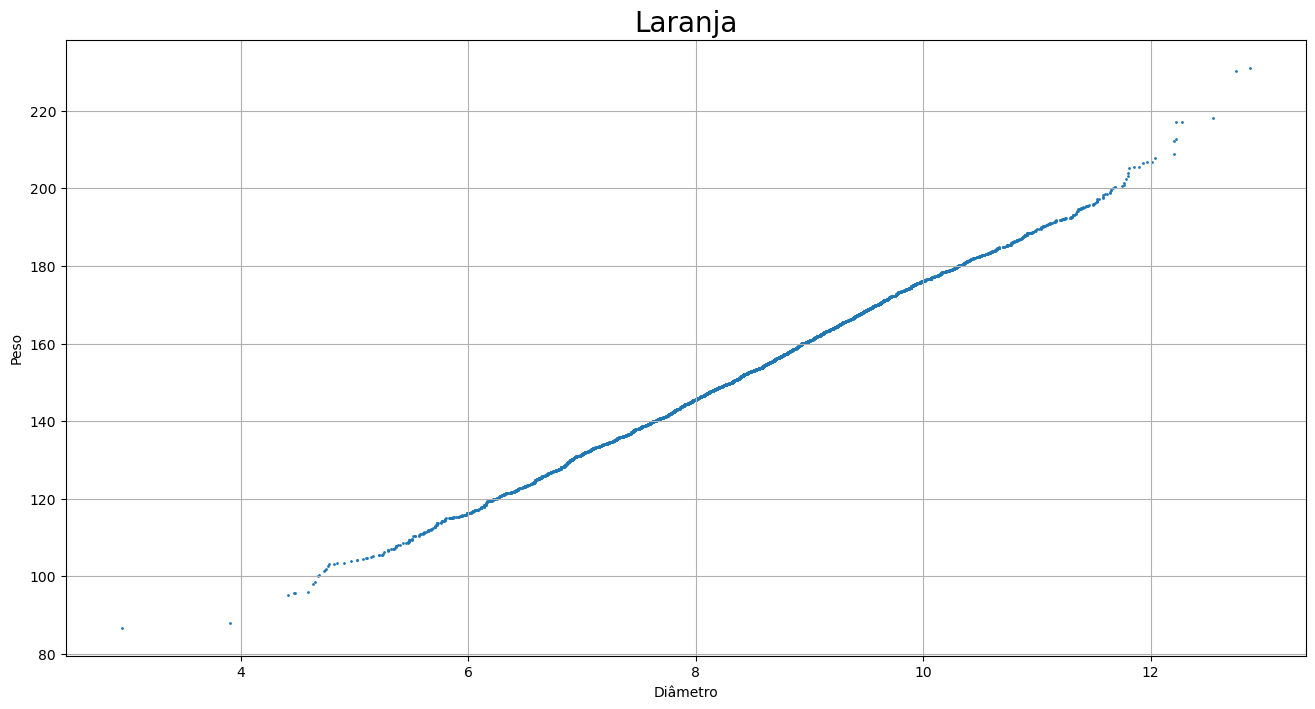

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plt.grid()
diametro_laranja = laranja[:,0]
peso_laranja = laranja[:,1]
plt.scatter(diametro_laranja, peso_laranja, s=1)
plt.xlabel(xlabel='Diâmetro')
plt.ylabel(ylabel='Peso')
plt.title('Laranja', fontsize=20)
plt.show()

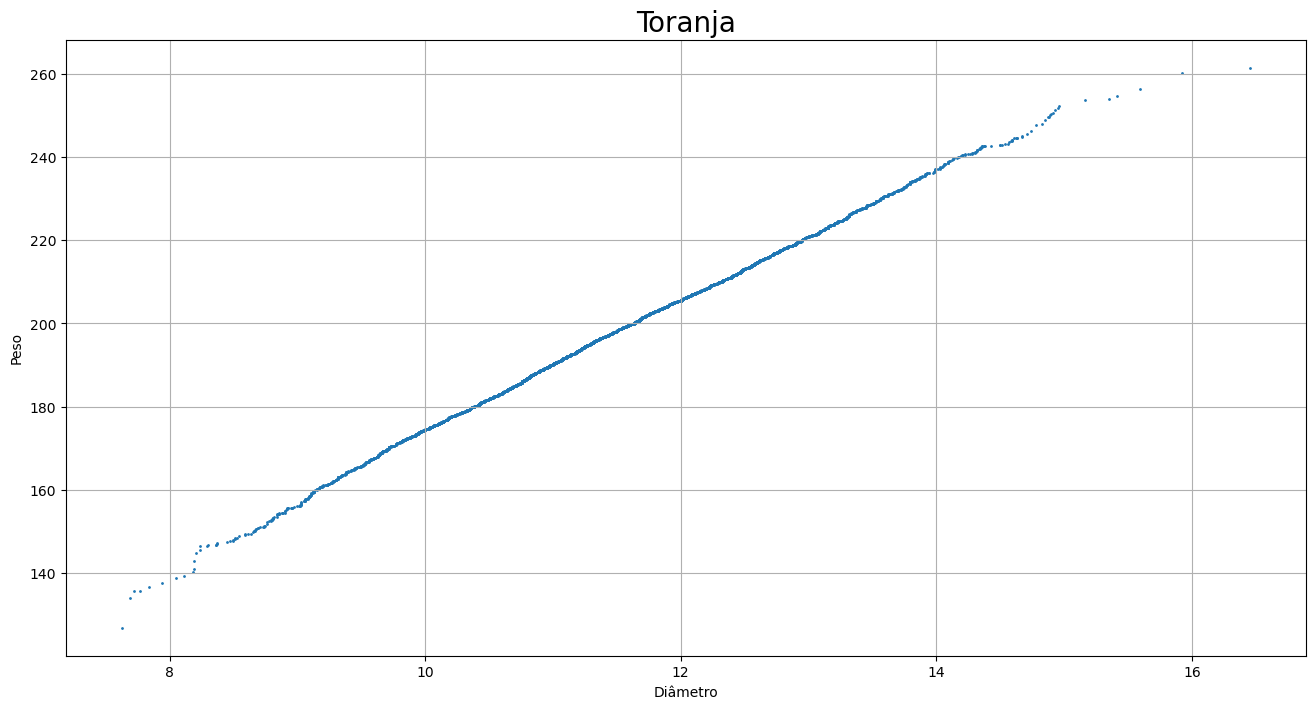

In [64]:
plt.figure(figsize=(16, 8))
plt.grid()
diametro_toranja = toranja[:,0]
peso_toranja = toranja[:,1]
plt.scatter(diametro_toranja, peso_toranja, s=1)
plt.xlabel(xlabel='Diâmetro')
plt.ylabel(ylabel='Peso')
plt.title('Toranja', fontsize=20)
plt.show()

### Agora você deve calcular o coeficiente ângular e o linear para a reta da laranja e para a reta da toranja.

Laranja:

In [56]:
param_laranja = np.polyfit(diametro_laranja, peso_laranja, 1)
retaX_laranja = [2.5,14]
retaY_laranja = [param_laranja[0]*retaX_laranja[0]+param_laranja[1],param_laranja[0]*retaX_laranja[1]+param_laranja[1]]

def pontos_reta_laranja(x):
    print(f'Para {x} centímetros de diâmetro a laranja deve ter {(param_laranja[0]*x+param_laranja[1]):.2f} gramas de peso')

pontos_reta_laranja(12)

Para 12 centímetros de diâmetro a laranja deve ter 204.98 gramas de peso


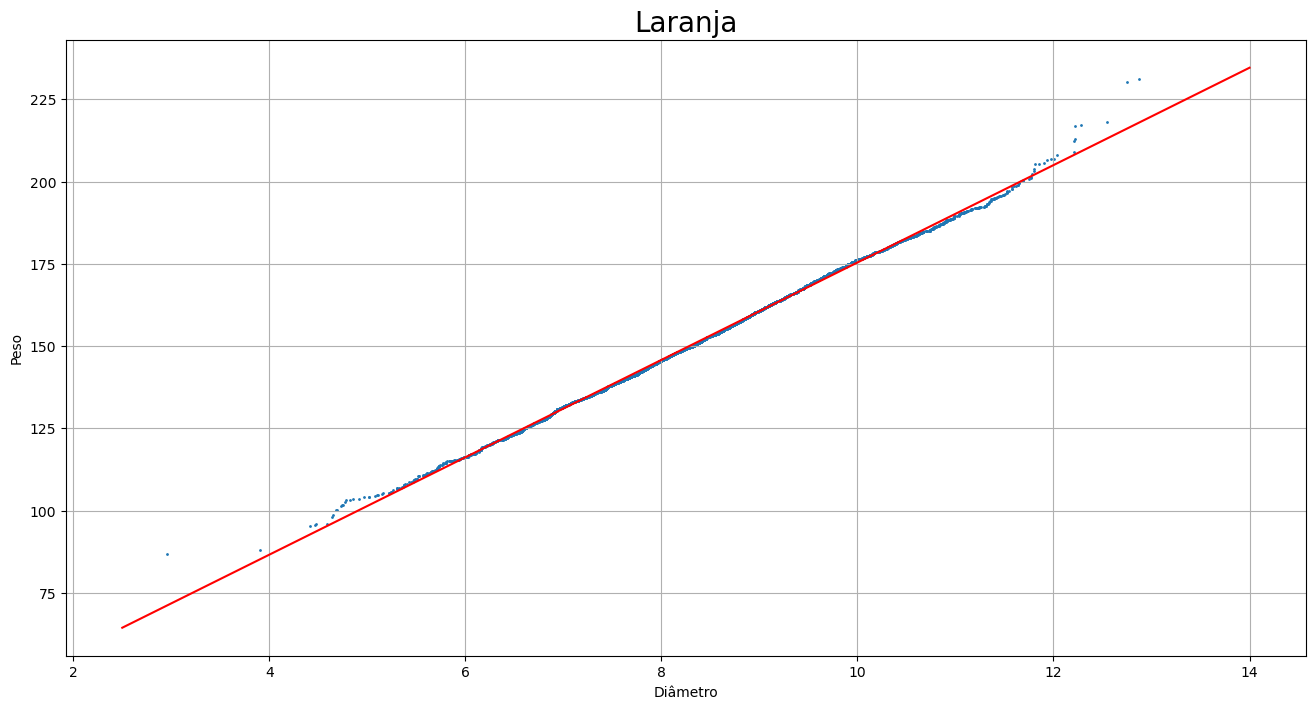

In [62]:
plt.figure(figsize=(16, 8))
plt.grid()
diametro_laranja = laranja[:,0]
peso_laranja = laranja[:,1]
plt.scatter(diametro_laranja, peso_laranja, s=1)
plt.xlabel(xlabel='Diâmetro')
plt.ylabel(ylabel='Peso')
plt.title('Laranja', fontsize=20)
plt.plot(retaX_laranja, retaY_laranja, color='red')
plt.show()

Toranja:

In [66]:
param_toranja = np.polyfit(diametro_toranja, peso_toranja, 1)
retaX_toranja = [7,17]
retaY_toranja = [param_toranja[0]*retaX_toranja[0]+param_toranja[1],param_toranja[0]*retaX_toranja[1]+param_toranja[1]]

def pontos_reta_toranja(x):
    print(f'Para {x} centímetros de diâmetro a toranja deve ter {(param_toranja[0]*x+param_toranja[1]):.2f} gramas de peso')

pontos_reta_toranja(12)

Para 12 centímetros de diâmetro a toranja deve ter 205.51 gramas de peso


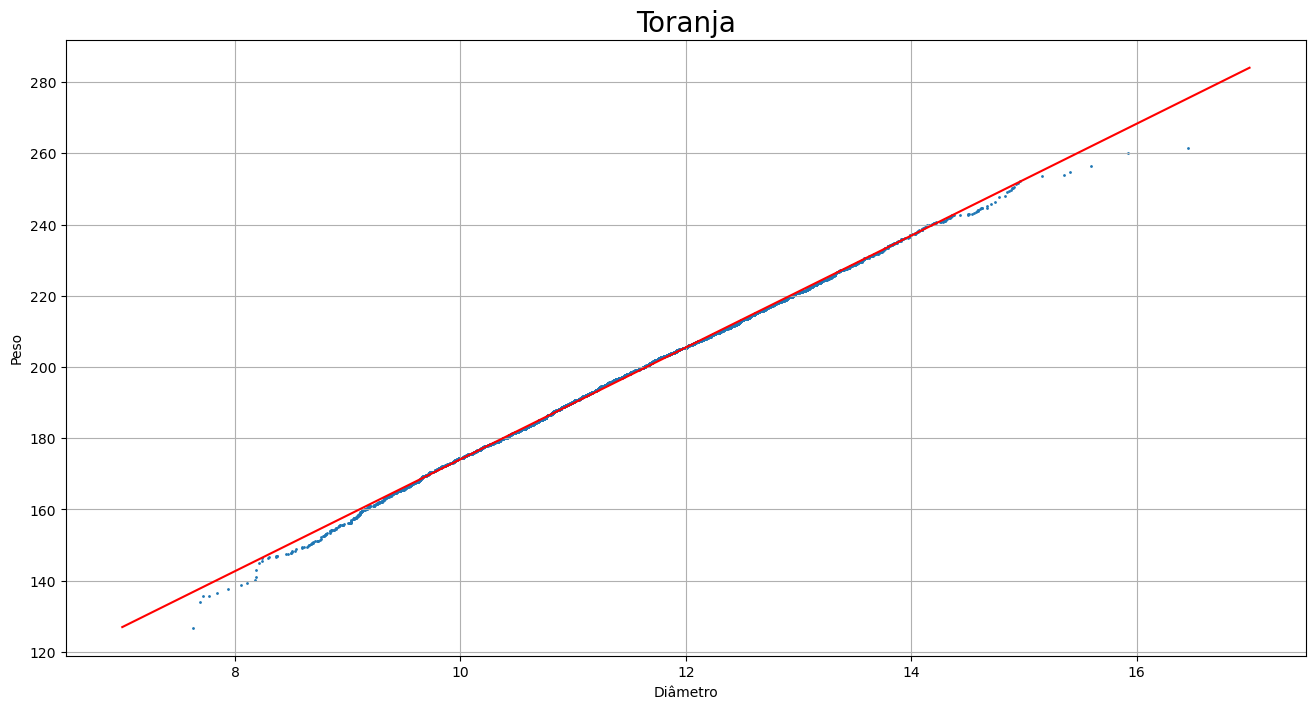

In [67]:
plt.figure(figsize=(16, 8))
plt.grid()
diametro_toranja = toranja[:,0]
peso_toranja = toranja[:,1]
plt.scatter(diametro_toranja, peso_toranja, s=1)
plt.xlabel(xlabel='Diâmetro')
plt.ylabel(ylabel='Peso')
plt.title('Toranja', fontsize=20)
plt.plot(retaX_toranja, retaY_toranja, color='red')
plt.show()